<a href="https://colab.research.google.com/github/Nahi05/ISSD-PH/blob/main/Delgado_Nahiara_PH_TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP1 PROCESAMIENTO DEL HABLA: webscrapping

Delgado Nahiara


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

Hago la solicitud de la información a la página de humandelopment y analizo el html del sitio.

In [ ]:
#Magnifica Humanitas - La Encíclica del Papa León XIV sobre la custodia de la persona humana en el tiempo de la inteligencia artificial
url= "https://www.humandevelopment.va/es/magnifica-humanitas.html" #sitio utilizado

respuesta= requests.get(url) #solicitud de url
respuesta.raise_for_status() #verificar que la descarga del sitio es exitosa, de lo contrario trabajaremos con un sitio vacío o fallido.

papa_soup= BeautifulSoup(respuesta.text, 'html.parser') #creación de soup, extraemos el contenido

In [ ]:
papa_soup.get_text() #extraemos el texto del sitio

'\n\n\n\n\n\nMagnifica Humanitas - Dicasterio para el Servicio del Desarrollo Humano Integral\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nBúsqueda\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n                Italiano\n\n                English\n\n                 Español\n\n                Français\n\n                Português\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nMagnifica Humanitas\n\n\nCarta Encíclica\n\n\nLanzamiento \n\n\n\nRecursos\n\n\n\n                                                Infografías\n\n\n\n                                                Vídeo de Presentación\n\n\n\n                                                Vídeo de lanzamiento\n\n\n\n                                                Kit Pastoral\n\n\n\n                                                Síntesis\n\n\n\n\nNewsletter\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\n\nMagnifica Humanitas\n

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

Instalo spacy

In [ ]:
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 90.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy #importo la librería
nlp= spacy.load('es_core_news_sm') #carga del modelo de spacy

texto= papa_soup.text #extraemos el texto limpio como strings

doc= nlp(texto) #pasamos el string al modelo

stopwords_es = [ #recorre cada token, comprueba si cada palabra es una stopword y se asegura de ignorar comas y puntos
    token.text for token in doc if token.is_stop and not token.is_punct
]

print(stopwords_es)

['para', 'el', 'del', 'de', 'de', 'La', 'del', 'sobre', 'la', 'de', 'la', 'en', 'el', 'de', 'la', 'La', 'del', 'ser', 'como', 'para', 'el', 'El', 'al', 'al', 'y', 'a', 'todo', 'el', 'de', 'su', 'primera', 'sobre', 'la', 'de', 'la', 'en', 'en', 'de', 'la', 'a', 'todos', 'los', 'de', 'la', 'y', 'de', 'la', 'a', 'unos', 'a', 'otros', 'con', 'los', 'y', 'en', 'la', 'de', 'una', 'más', 'y', 'Por', 'con', 'ustedes', 'el', 'de', 'y', 'ser', 'de', 'para', 'la', 'de', 'nuestro', 'Que', 'el', 'del', 'nuestro', 'La', 'en', 'En', 'la', 'era', 'de', 'la', 'la', 'se', 'a', 'una', 'por', 'la', 'y', 'el', 'como', 'sobre', 'los', 'que', 'nuestra', 'o', 'la', 'de', 'la', 'en', 'el', 'el', 'a', 'la', 'de', 'Para', 'esta', 'el', 'a', 'dos', 'por', 'un', 'lado', 'la', 'de', 'la', 'de', 'y', 'por', 'el', 'otro', 'la', 'de', 'Para', 'el', 'se', 'un', 'en', 'la', 'de', 'la', 'las', 'del', 'e', 'nuestros', 'a', 'la', 'del', 'para', 'poder', 'a', 'la', 'la', 'verdad', 'incluso', 'a', 'través', 'de', 'los', 'Par

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

In [ ]:
!pip install WordCloud

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
stopwords_es= set(stopwords.words('spanish')) #obtengo la lista de stopwords en español

#extraigo el texto del soup y limpio stopwords y caracteres extraños.
texto=papa_soup.text.lower()
palabras=texto.split()

#mantengo solo las palabras alfabeticas y que no sean stopwords
filtro= [p for p in palabras if p.isalpha() and p not in stopwords_es]

#unir las palabras filtradas en una cadena de texto
text_limpio= ' '.join(filtro)

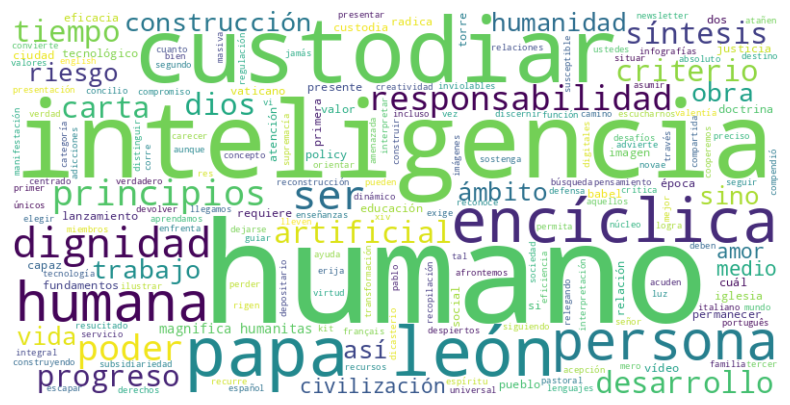

In [ ]:
#generar la nube y graficarla con matplotlib
nube= WordCloud(width=800, height=400, background_color="white").generate(text_limpio)

plt.figure(figsize=(10,5))
plt.imshow(nube,interpolation="bilinear")
plt.axis("off")
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 37.1 MB/s eta 0:00:00


In [ ]:
#usaré spacy para decomponer el texto en oraciones
doc= nlp(texto)

oraciones= [sent.text for sent in doc.sents]

print(f"cantidad de oraciones: {len(oraciones)}")

cantidad de oraciones: 39


In [ ]:
from gensim.utils import simple_preprocess

stop_words_es= set(stopwords.words('spanish'))

docu= [] #cada elemento de acá es una oración ya preprocesada

for oracion in oraciones:
  tokens= simple_preprocess(oracion, deacc=True)

  filtro=[word for word in tokens if word not in stop_words_es]
  docu.append(filtro)

#verifico que está todo en orden
print("primeras 5 oraciones procesadas:")
for documento in docu[:5]:
    print(documento)

primeras 5 oraciones procesadas:
[]
['magnifica', 'humanitas', 'dicasterio', 'servicio', 'desarrollo', 'humano', 'integral', 'busqueda', 'italiano', 'english', 'espanol', 'francais', 'portugues', 'magnifica', 'humanitas', 'carta', 'enciclica', 'lanzamiento', 'recursos', 'infografias', 'video', 'presentacion', 'video', 'lanzamiento', 'kit', 'pastoral', 'sintesis', 'newsletter', 'magnifica', 'humanitas', 'enciclica', 'papa', 'leon', 'xiv', 'custodia', 'persona', 'humana', 'tiempo', 'inteligencia', 'artificial', 'dignidad', 'ser', 'humano', 'criterio', 'orientar', 'progreso', 'tecnologico']
['papa', 'leon', 'xiv', 'presentar', 'mundo', 'pueblo', 'dios', 'primera', 'carta', 'enciclica', 'custodia', 'persona', 'humana', 'tiempo', 'inteligencia', 'artificial', 'declaro', 'invito', 'miembros', 'iglesia', 'familia', 'humana', 'aprendamos', 'escucharnos', 'afrontemos', 'valentia', 'desafios', 'presentes', 'cooperemos', 'construccion', 'sociedad', 'mas', 'humana', 'fraterna']
['favor', 'lleven',

In [ ]:
vocab= []

for documento in docu:
  for palabra in documento:
    if palabra not in vocab:
      vocab.append(palabra)

print("cantidad de palabras en el vocabulario:", len(vocab))
print("primeras 20 palabras:", vocab[:20])

cantidad de palabras en el vocabulario: 401
primeras 20 palabras: ['magnifica', 'humanitas', 'dicasterio', 'servicio', 'desarrollo', 'humano', 'integral', 'busqueda', 'italiano', 'english', 'espanol', 'francais', 'portugues', 'carta', 'enciclica', 'lanzamiento', 'recursos', 'infografias', 'video', 'presentacion']


In [ ]:
matriz= []

for documento in docu:
  fila= []

  for palabra in vocab:
    fila.append(documento.count(palabra))

  matriz.append(fila)

matriz= pd.DataFrame(matriz, columns=vocab)

print(matriz.shape)
matriz.head()

(39, 401)


,magnifica,humanitas,dicasterio,servicio,desarrollo,humano,integral,busqueda,italiano,english,...,contactos,enlaces,utiles,creditos,privacy,policy,cookie,palazzo,san,calisto
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,3,3,1,1,1,2,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



#### 2.3.2 Determina la longitud de tu vocabulario.

In [ ]:
long_vocab= len(vocab)
print(f"la longitud del vocabulario es: {long_vocab}")

la longitud del vocabulario es: 401



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [ ]:
from gensim import corpora, models

diccionario = corpora.Dictionary(docu)
corpus_bow = [diccionario.doc2bow(oracion) for oracion in docu]
modelo_tfidf = models.TfidfModel(corpus_bow)
corpus_tfidf = modelo_tfidf[corpus_bow]

palabra_a_indice = {palabra: i for i, palabra in enumerate(vocab)}

matriz_tfidf = []
for oracion_tfidf in corpus_tfidf:
    fila = [0.0] * len(vocab)
    for id_palabra, peso in oracion_tfidf:
        palabra = diccionario[id_palabra]
        if palabra in palabra_a_indice:
            fila[palabra_a_indice[palabra]] = peso
    matriz_tfidf.append(fila)

matriz_tfidf = pd.DataFrame(matriz_tfidf, columns=vocab)

print("forma de la matriz TF-IDF (documentos x vocabulario):", matriz_tfidf.shape)
matriz_tfidf.head(20)

forma de la matriz TF-IDF (documentos x vocabulario): (39, 401)


,magnifica,humanitas,dicasterio,servicio,desarrollo,humano,integral,busqueda,italiano,english,...,contactos,enlaces,utiles,creditos,privacy,policy,cookie,palazzo,san,calisto
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.419612,0.419612,0.139871,0.139871,0.097927,0.131156,0.113407,0.139871,0.139871,0.139871,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Al comparar matriz_tfidf con matriz (la de frecuencias), ambas tienen exactamente la misma forma — mismas filas, mismas columnas, en el mismo orden — porque construí la matriz TF-IDF respetando el mismo vocabulario. Lo que cambia es el contenido: donde la matriz de frecuencias solo cuenta apariciones, la matriz TF-IDF pondera esas apariciones según qué tan característica es cada palabra de una oración en particular frente al resto del corpus. Es esperable que la mayoría de las celdas sean 0 (una matriz "dispersa"), ya que cada oración es corta y usa solo una pequeña fracción de las 401 palabras del vocabulario total del texto.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

En este trabajo práctico partí del texto  la Encíclica Magnifica Humanitas del Papa León XIV mediante web scraping y apliqué sobre él un pipeline completo de preprocesamiento y vectorización de texto en español, usando tres librerías distintas de NLP: spaCy, NLTK y gensim.

El proceso de scraping en sí fue sencillo (una solicitud HTTP con requests y un parseo del HTML con BeautifulSoup), pero puso en evidencia algo importante: el texto "crudo" que se obtiene de una página web nunca está listo para analizar directamente. Necesité varias capas de limpieza — eliminación de stopwords (primero con spaCy, después con NLTK, para comparar ambos enfoques), filtrado de caracteres no alfabéticos, y finalmente una limpieza adicional con expresiones regulares para sacar residuos propios del scraping, como saltos de línea pegados a palabras o símbolos sueltos que el filtro simple no detectaba.

A partir de ese texto limpio construí dos tipos de representación. Primero, una representación visual e intuitiva: la nube de palabras, que permite identificar de un vistazo los términos más frecuentes y hacerse una idea rápida del tema central del texto. Segundo, dos representaciones numéricas más rigurosas: una matriz documento-vocabulario por frecuencia (bolsa de palabras) y su versión ponderada con TF-IDF, calculada con gensim.

Como limitación del trabajo, no apliqué stemming ni lematización, dos técnicas que reducen distintas formas de una misma palabra (por ejemplo, "gobierna" y "gobernando") a una raíz o forma base común. Apliqué lematización con spaCy.

Este TP me permitió entender en la práctica que el preprocesamiento de texto no es un paso secundario, sino el que más determina la calidad de cualquier análisis: la elección de qué stopwords sacar, cómo tokenizar y qué representación vectorial usar cambia directamente los resultados que se obtienen.


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [ ]:
# instalar wordcloud
!pip install wordcloud


In [ ]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [ ]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

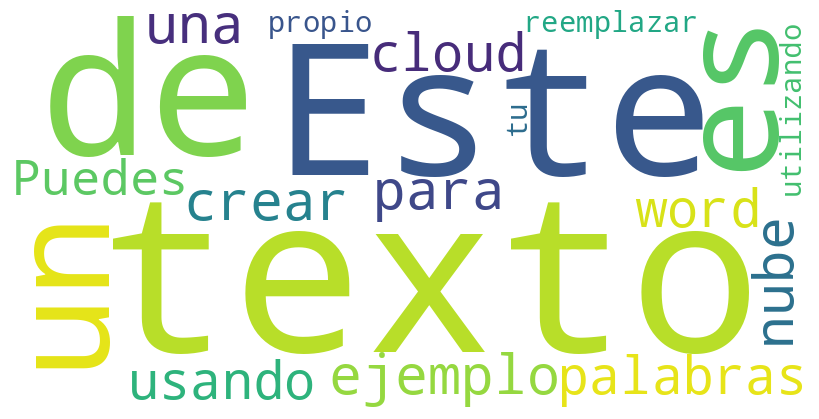

In [ ]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



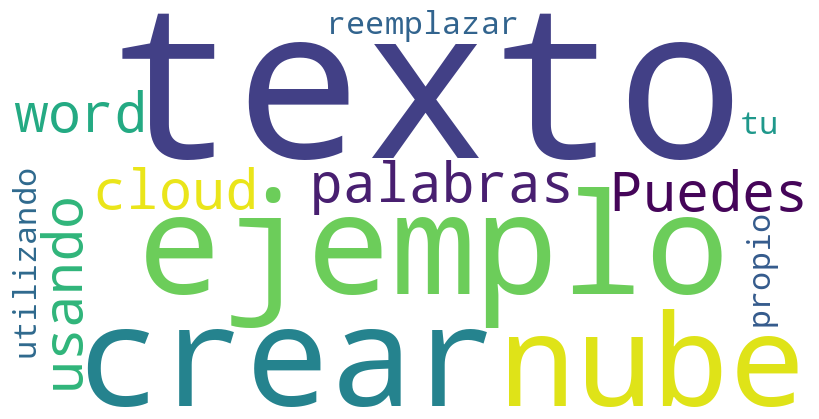

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
